In [88]:
from shinka.utils import load_programs_to_df

path = "results/results_stlc_async_small/"
programs_df, prompts_df = load_programs_to_df(path, include_prompts=True)

Total program rows: 39
Correct program rows: 34
Total cost: $0.52
Avg cost per program: $0.01
Total prompt rows: 8
Prompts in archive: 8


In [89]:
programs_df.head()

,id,code,language,parent_id,archive_inspiration_ids,top_k_inspiration_ids,generation,timestamp,complexity,embedding,...,temperature,max_output_tokens,llm_result,results_missing,safe_processing,meta_cost,meta_recommendations,meta_summary,meta_scratch_pad,total_cost
0,57c8bd9e-dd2f-4ca6-bdcf-d322aee1ad9e,"from typing import Literal, Tuple\nimport rand...",python,NaN,[],[],0,2026-03-15 06:55:04.049256086,0.679,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,fb7b1078-6af2-4cdc-b240-33b14a687225,"from typing import Literal, Tuple\nimport rand...",python,57c8bd9e-dd2f-4ca6-bdcf-d322aee1ad9e,[],[],2,2026-03-15 06:55:13.608105898,0.597,[],...,1.0,32768.0,{'content': '<NAME> stlc_generator_v1 </NAME> ...,False,True,NaN,NaN,NaN,NaN,0.004347
2,25b05571-7cf1-4268-a2f8-93fbe00f500c,"from typing import Literal, Tuple\nimport rand...",python,57c8bd9e-dd2f-4ca6-bdcf-d322aee1ad9e,[],[],1,2026-03-15 06:55:14.953030109,0.619,[],...,1.0,32768.0,{'content': '<NAME> stlc_random_generator </NA...,False,True,NaN,NaN,NaN,NaN,0.004881
3,0478340d-7969-4029-82a7-d2c015a5b349,"from typing import Literal, Tuple\nimport rand...",python,fb7b1078-6af2-4cdc-b240-33b14a687225,[57c8bd9e-dd2f-4ca6-bdcf-d322aee1ad9e],[],4,2026-03-15 06:55:25.213107109,0.609,[],...,0.5,32768.0,{'content': '<NAME> improve_term_usage_and_siz...,False,True,NaN,NaN,NaN,NaN,0.005378
4,38978859-960e-46c5-a169-102dd6b1ee05,"from typing import Literal, Tuple\nimport rand...",python,fb7b1078-6af2-4cdc-b240-33b14a687225,[57c8bd9e-dd2f-4ca6-bdcf-d322aee1ad9e],[],3,2026-03-15 06:55:25.546773911,0.612,[],...,0.5,32768.0,{'content': '<NAME> contextual_backtracking_ge...,False,True,0.013538,NaN,NaN,NaN,0.019915


Filtered to 34 'correct' rows from 39 total.
GraphViz not available, using hierarchical layout


/Users/henryblanchette/Documents/ShinkaEvolve/shinka/plots/plot_lineage_tree.py:384: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/henryblanchette/Documents/ShinkaEvolve/shinka/plots/plot_lineage_tree.py:398: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/henryblanchette/Documents/ShinkaEvolve/.venv/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: You passed a edgecolor/edgecolors ('darkred') for an unfilled marker (np.str_('x'))

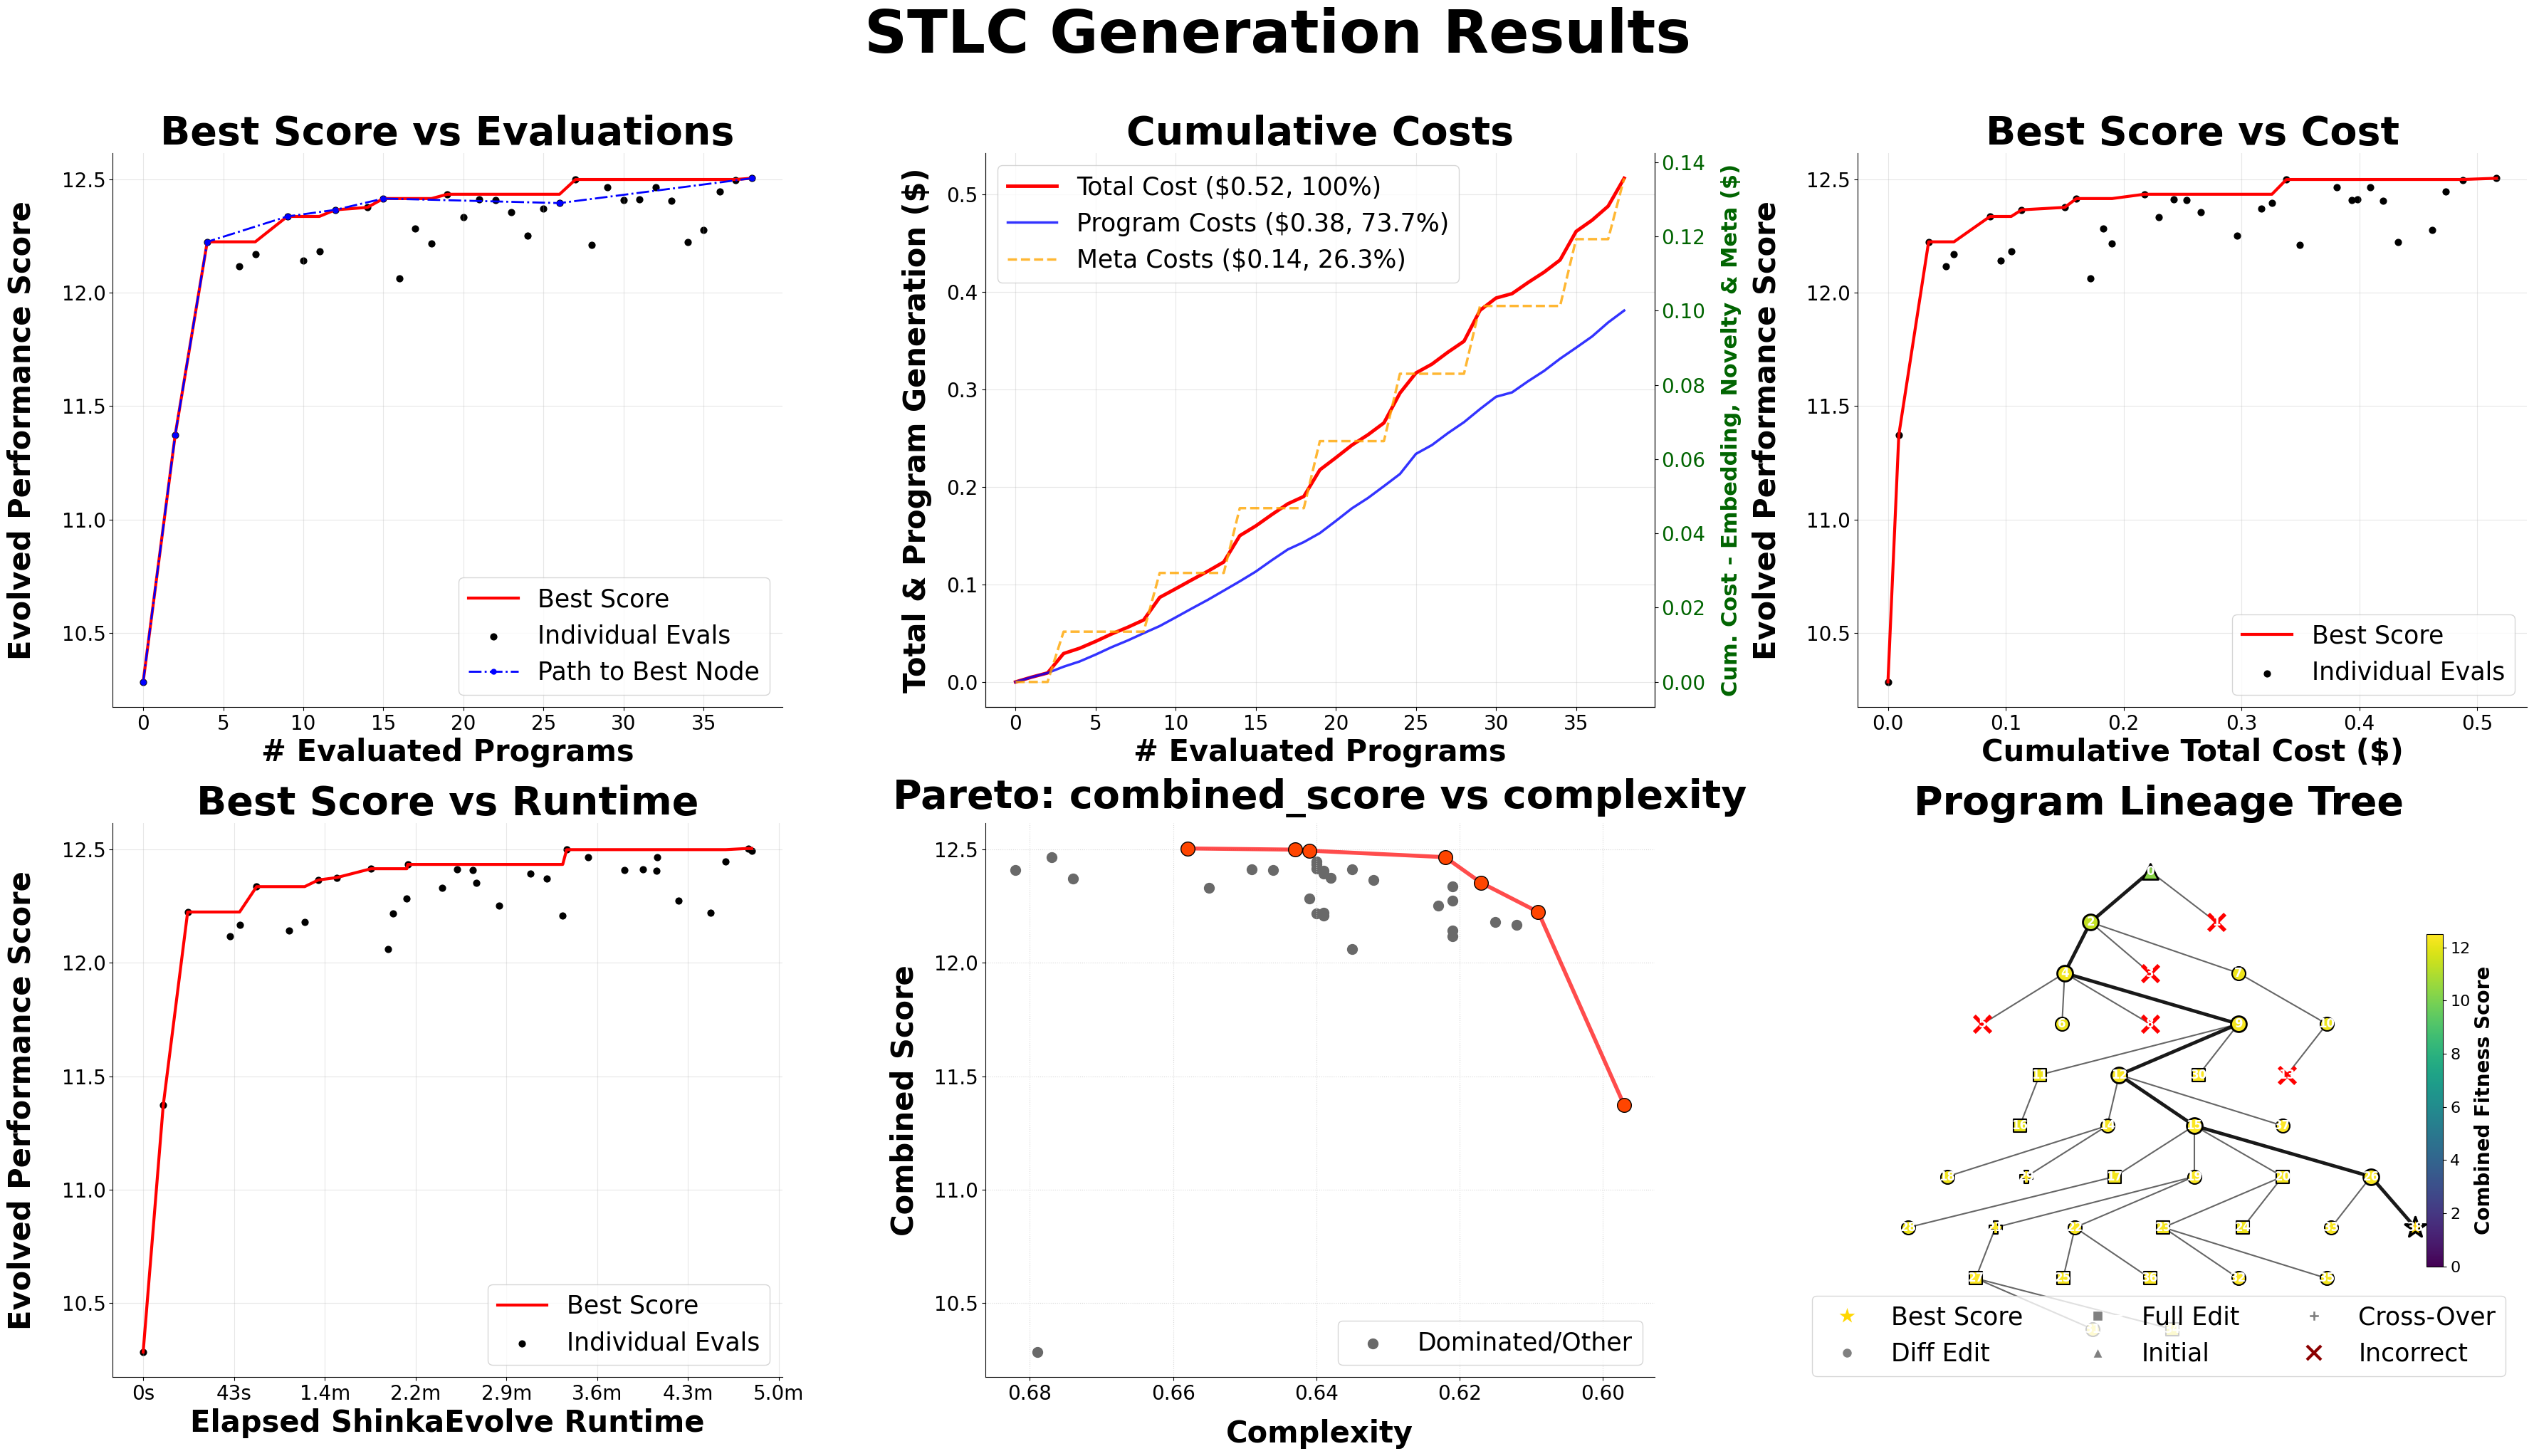

In [90]:
import matplotlib.pyplot as plt

from shinka.plots import plot_evals_performance
from shinka.plots import plot_costs
from shinka.plots import plot_cost_performance
from shinka.plots import plot_time_performance
from shinka.plots import plot_pareto_curve
from shinka.plots import plot_lineage_tree

if programs_df is None or programs_df.empty:
    raise ValueError(
        "No program data loaded. Update `path` in cell 0 to a valid results directory."
    )

fig, axs = plt.subplots(2, 3, figsize=(36, 20))
fig.suptitle("STLC Generation Results", fontsize=60, weight="bold", y=1.02)

plot_evals_performance(
    programs_df,
    title="Best Score vs Evaluations",
    fig=fig,
    ax=axs[0, 0],
    annotate=False,
    show_cost=False,
)

plot_costs(
    programs_df,
    title="Cumulative Costs",
    fig=fig,
    ax=axs[0, 1],
)

plot_cost_performance(
    programs_df,
    title="Best Score vs Cost",
    fig=fig,
    ax=axs[0, 2],
)

plot_time_performance(
    programs_df,
    title="Best Score vs Runtime",
    fig=fig,
    ax=axs[1, 0],
)

# Pick a Pareto pair that usually exists in Shinka results.
if "loc" in programs_df.columns:
    pareto_x, pareto_y = "loc", "combined_score"
    x_maximize, y_maximize = False, True
elif "complexity" in programs_df.columns:
    pareto_x, pareto_y = "complexity", "combined_score"
    x_maximize, y_maximize = False, True
elif "total_cost" in programs_df.columns:
    pareto_x, pareto_y = "total_cost", "combined_score"
    x_maximize, y_maximize = False, True
else:
    pareto_x, pareto_y = "generation", "combined_score"
    x_maximize, y_maximize = True, True

plot_pareto_curve(
    programs_df,
    x_variable=pareto_x,
    y_variable=pareto_y,
    x_maximize=x_maximize,
    y_maximize=y_maximize,
    title=f"Pareto: {pareto_y} vs {pareto_x}",
    fig=fig,
    ax=axs[1, 1],
    annotate=False,
)

plot_lineage_tree(
    programs_df,
    title="Program Lineage Tree",
    fig=fig,
    ax=axs[1, 2],
)

plt.tight_layout()
plt.show()
